### Ablation waterfall

Each step adds one capability to the one before it, so the bar height is what
that capability is worth. Zero-shot LLMs are a separate figure
(`llm_comparison.ipynb`) -- they skip every step, so they don't belong on
the chain.

Reads `results.csv`, writes `ablation_waterfall.png`.

In [1]:
import sys

sys.path.insert(0, "..")
from config import RESULTS_DIR

import textwrap

import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Rectangle

# match the thesis body font (Computer Modern)
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["cmr10", "DejaVu Serif"],
        "font.monospace": ["cmtt10", "DejaVu Sans Mono"],
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
    }
)

d = (
    pl.read_csv(RESULTS_DIR / "results.csv")
    .filter(pl.col("corpus") == "twd")  # chrono rows would pollute the means
    .group_by("model")
    .agg(pl.col("macro_f1").mean().alias("m"))
)
m = dict(zip(d["model"], d["m"]))

# each step adds exactly one capability to the one before it
CHAIN = [
    ("random", "random\nguess", "chance floor"),
    ("rule-based", "rule-based", "hand-coded rules"),
    ("bow", "bag-of-\nwords", "word counts"),
    ("word2vec", "word2vec", "static embeddings"),
    ("frozen:bert-base-uncased", "frozen\nBERT-base", "context (attention)"),
    ("frozen:bert-large-uncased", "frozen\nBERT-lg", "3x parameters"),
    ("frozen:roberta-large", "frozen\nRoBERTa-lg", "better pretraining"),
    ("roberta-large", "finetuned\nRoBERTa-lg", "fine-tune encoder"),
]

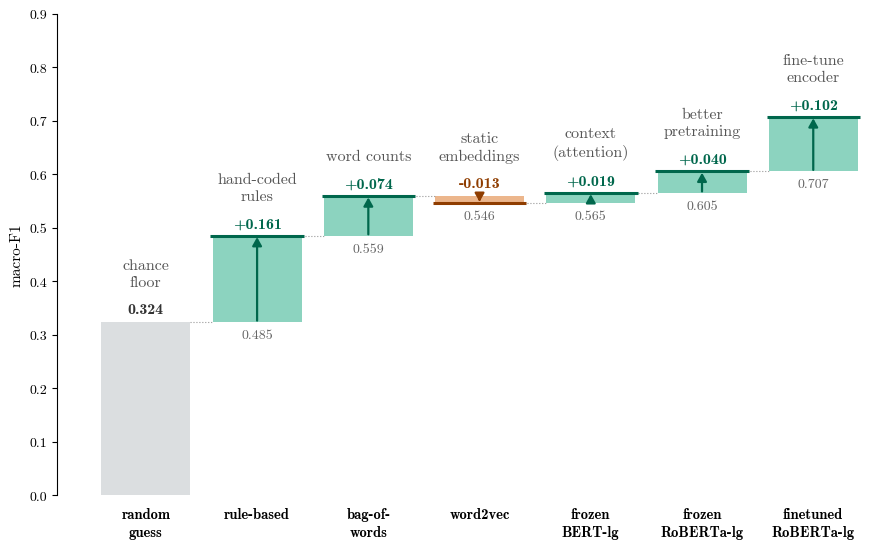

In [2]:
# Okabe-Ito: bluish green vs vermillion stays distinguishable under red-green
# colour blindness, unlike the usual green/red pair. Arrows encode direction too.
UP, DOWN, BASE = "#009E73", "#D55E00", "#9aa3ab"
UPD, DOWND = "#00674C", "#8F3D00"  # darker, for arrows and the landing rule
FILL = 0.45  # fills kept light so arrows and rules read
ticks, names = [], []

fig, ax = plt.subplots(figsize=(9.4, 5.8))

x, prev = 0, None
for key, name, what in CHAIN:
    v = m[key]
    if prev is None:
        ax.add_patch(Rectangle((x - 0.4, 0), 0.8, v, facecolor=BASE, alpha=FILL))
        top, lbl, col = v, f"{v:.3f}", "#2b3440"
    else:
        lo, hi = min(prev, v), max(prev, v)
        up = v > prev
        ax.add_patch(
            Rectangle(
                (x - 0.4, lo), 0.8, hi - lo, facecolor=UP if up else DOWN, alpha=FILL
            )
        )
        # arrow shows the direction of travel, so the red step reads as a fall
        ax.annotate(
            "",
            xy=(x, v),
            xytext=(x, prev),
            arrowprops=dict(
                arrowstyle="-|>,head_width=0.28,head_length=0.5",
                color=UPD if up else DOWND,
                lw=1.6,
                shrinkA=1,
                shrinkB=1,
            ),
        )
        # heavy rule at the value we land on
        ax.plot(
            [x - 0.42, x + 0.42],
            [v, v],
            color=UPD if up else DOWND,
            lw=2.2,
            solid_capstyle="butt",
            zorder=4,
        )
        ax.plot([x - 0.6, x - 0.4], [prev, prev], color="#6b7280", lw=0.8, ls=":")
        ax.text(x, lo - 0.03, f"{v:.3f}", ha="center", fontsize=10, color="#4b5563")
        top, lbl, col = hi, f"{v - prev:+.3f}", UPD if up else DOWND
    ax.text(
        x, top + 0.016, lbl, ha="center", fontsize=11.5, fontname="cmb10", color=col
    )
    ax.text(
        x,
        top + 0.062,
        textwrap.fill(what, 11),
        ha="center",
        va="bottom",
        fontsize=11.5,
        color="#44494f",
        linespacing=1.3,
    )
    ticks.append(x)
    names.append(name)
    prev = v
    x += 1

ax.set_xticks(ticks)
ax.set_xticklabels(names, fontsize=11.5, fontname="cmr10", linespacing=1.4)
ax.tick_params(axis="x", length=0, pad=8)
ax.set_ylim(0, 0.90)
ax.set_xlim(-0.8, x - 0.4)
ax.set_ylabel("macro-F1 on test (mean of 3 seeds)", fontsize=13, fontname="cmb10")
ax.set_xlabel("system, in order of increasing capability", fontsize=13, labelpad=10, fontname="cmb10")
ax.tick_params(axis="y", labelsize=11.5)
for s in ("top", "right", "bottom"):
    ax.spines[s].set_visible(False)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig("ablation_waterfall.png", dpi=200, bbox_inches="tight", facecolor="white")
fig.savefig("ablation_waterfall.pdf", bbox_inches="tight", facecolor="white")

### Reading the chain

Each step adds one capability to the one before it.

1. Random guess — uniform over 3 classes.

2. Hand-coded rules — a dictionary of economic nouns paired with direction verbs, plus a
   negation list. Nothing is learned. A sentence is scored by which words it contains.
3. Word counts — each sentence becomes a vector of token counts, one dimension per word.
   Logistic regression learns a weight per token. Word order discarded.
4. Word2Vec — each word carries one fixed 300-dimensional vector, the same in every
   sentence, learned across 100 billion words of news. A sentence is the mean of its word vectors.
5. Frozen BERT-base — attention rebuilds each word's vector from its neighbours, so the
   same word differs by sentence context. The encoder is frozen; the vectors are mean-pooled
   and only a classifier sits on top.
6. Frozen BERT-large — the same encoder at roughly 3x the parameters, still frozen.
7. Frozen RoBERTa-large — same architecture as BERT-large, retrained better: ~10x the
   amount of text, a fresh mask per epoch rather than one fixed at preprocessing.
8. Fine-tuning — all 355M encoder weights are updated on the labelled examples, not just
   the classifier head. The biggest jump outside the initial jump from the random guess baseline.


Sources: 

rule-based dictionary Gorodnichenko, Pham & Talavera (2021); 

word2vec Mikolov et al.(2013); 

BERT Devlin et al. (2018);

RoBERTa Liu et al. (2019); 

benchmark data, Shah et al. (2023).